# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU4.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.


## 1. Spinograf
- **Úkol: nakreslete obrázek trajektorie bodu na spinografu pro zadané hodnoty**
    - $R$ (poloměr větší kružnice),
    - $r$ (poloměr menší kružnice),
    - $d$ (vzdálenost bodu od středu menší kružnice).
- Rozmyslete si, kolik rotací musí menší kružnice udělat, aby se bod vrátil do své původní pozice (vykreslete dráhu tak, aby byla uzavřená).
- Vyzkoušejte alespoň pro $R=10, r=3, d=1$ a $R=7, r=2, d=5$.
- Vykreslete pomocí tenké modré čáry; zvolte dostatek bodů, aby byla trajektorie plynulá.

---

### Co je to spinograf?
Jedná se o hru/výukovou pomůcku (viz https://en.wikipedia.org/wiki/Spirograph).

Pro vysvětlení trajektorie bodu na spinografu (často označovaného jako hypotrochoida, když se menší kružnice otáčí uvnitř větší kružnice) použijeme goniometrický popis polohy bodu na kružnici v závislosti na úhlu rotace. Máme jednu větší kružnici s poloměrem $R$ a jednu menší kružnici s poloměrem $r$ a chceme trasovat dráhu bodu, který je od středu menší kružnice vzdálen o vzdálenost $d$.

### Poloha středu menší kružnice

Střed menší kružnice se otáčí uvnitř větší kružnice. Poloha středu menší kružnice v závislosti na úhlu $\theta$ je dána parametrickými rovnicemi v kartézských souřadnicích:

- $X = (R - r) \cos(\theta)$
- $Y = (R - r) \sin(\theta)$

kde $\theta$ je úhel rotace středu menší kružnice v radiánech.

### Otočení menší kružnice

Menší kružnice se otočí (valí se po větší kružnici). Úhel, o který se menší kružnice otočila ve svém vlastním středu vzhledem k počátečnímu bodu, je dán délkou oblouku, který urazila:
$$\theta R$$

Pokud chceme tento oblouk vyjádřit vzhledem k úhlu otočení v radiánech, o který se otočila menší kružnice ve svém středu, převádíme zpětně z obvodu na úhel:
$$\theta \frac{R}{r}$$

Poslední dvě důležitá pozorování jsou:
- malá kružnice se otočí negativně (tedy úhel je záporný),
- malá kružnice se otočí zároveň se svým středem, tedy k úhlu otočení musíme přičíst úhel $\theta$.

Celkově máme:

$$\phi = \theta - \theta \frac{R}{r} = - \theta \frac{R-r}{r}$$

### Pozice bodu na spinografu

Nakonec sloučíme pozici středu a relativní pozici bodu ve vzdálenosti $d$ od středu menší kružnice:

- $x = X + d \cos(\phi) = (R - r) \cos(\theta) + d \cos\left(- \theta \frac{R-r}{r}\right)$
- $y = Y + d \sin(\phi) = (R - r) \sin(\theta) + d \sin\left(- \theta \frac{R-r}{r}\right)$

Pokud použijeme vlastnosti (sudost/lichost) goniometrických funkcí, můžeme tyto rovnice zjednodušit na:

$$x = (R - r) \cos(\theta) + d \cos\left(\theta \frac{R-r}{r}\right)$$
$$y = (R - r) \sin(\theta) - d \sin\left(\theta \frac{R-r}{r}\right)$$

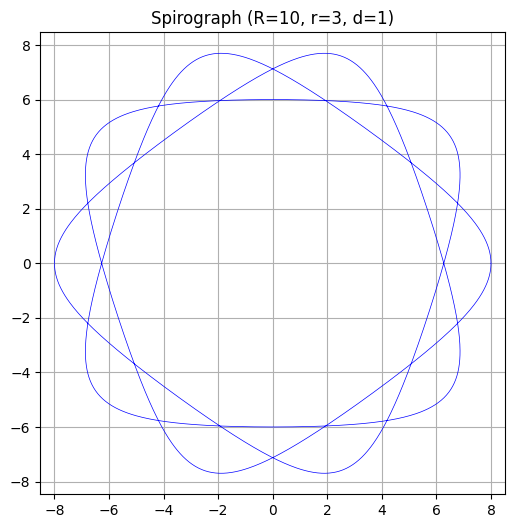

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

R = 10
r = 3
d = 1

revolutions = r // gcd(R, r)
theta = np.linspace(0, 2 * np.pi * revolutions, 2000)

x = (R - r) * np.cos(theta) + d * np.cos((R - r) * theta / r)
y = (R - r) * np.sin(theta) - d * np.sin((R - r) * theta / r)

plt.figure(figsize=(6, 6))
plt.plot(x, y, color='blue', linewidth=0.5)
plt.axis('equal')
plt.title(f"Spirograph (R={R}, r={r}, d={d})")
plt.grid(True)
plt.show()

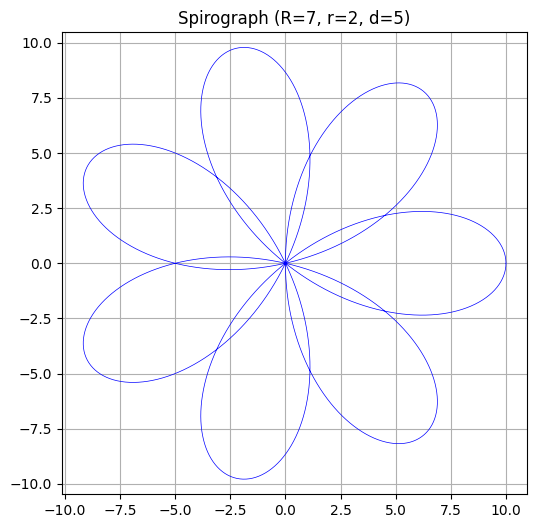

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

R = 7
r = 2
d = 5

revolutions = r // gcd(R, r)
theta = np.linspace(0, 2 * np.pi * revolutions, 2000)

x = (R - r) * np.cos(theta) + d * np.cos((R - r) * theta / r)
y = (R - r) * np.sin(theta) - d * np.sin((R - r) * theta / r)

plt.figure(figsize=(6, 6))
plt.plot(x, y, color='blue', linewidth=0.5)
plt.axis('equal')
plt.title(f"Spirograph (R={R}, r={r}, d={d})")
plt.grid(True)
plt.show()

## 2. Prvočíselná spirála

**Část 1: Vykreslení „slunečnicových bodů“**

- Vykreslete tzv. slunečnicové body, tedy prvních `N` takových bodů.
- Vykreslete je tak, aby byl vzor dobře vidět (zvolte vhodnou velikost bodů).

### Co jsou to slunečnicové body?
Poloměr $r$ a úhel $\theta$ pro každý bod (číslovaný přirozenými čísly: $n=1,\ldots,N$) jsou určeny následovně:

1. Zlatý úhel $\phi$ je dán vztahem:
$$
\phi = \pi \cdot (3 - \sqrt{5})
$$

2. Poloměr $r$ je odvozen z indexu bodu $n$ jako:
$$
r = \sqrt{n}
$$

3. Úhel $\theta$ pro bod $n$ je vypočítán jako:
$$
\theta = n \cdot \phi
$$

Každý bod je poté umístěn pomocí kartézských souřadnic $(x, y)$, které jsou vypočítány jako:
$$
x = r \cdot \cos(\theta)
$$
$$
y = r \cdot \sin(\theta)
$$

**Část 2: Vykreslení prvočíselné spirály**
- Vykreslete prvočíselnou spirálu pro prvních `N` prvočísel.
- Jedná se o stejný vzor jako v případě slunečnicových bodů, ale tentokrát vykreslete pouze body, které odpovídají prvočíslům.

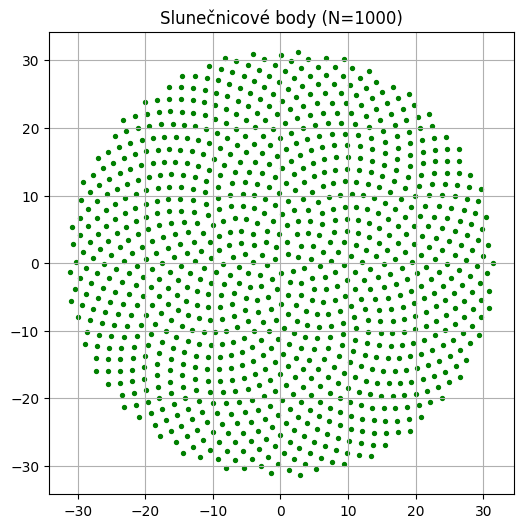

In [6]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
phi = np.pi * (3 - np.sqrt(5))

n = np.arange(1, N + 1)
r = np.sqrt(n)
theta = n * phi

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=8, color='green')
plt.axis('equal')
plt.title(f"Slunečnicové body (N={N})")
plt.grid(True)
plt.show()

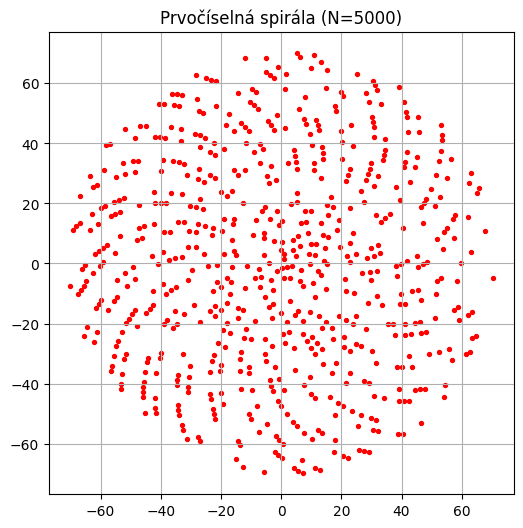

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0:
            return False
    return True

N = 5000
phi = np.pi * (3 - np.sqrt(5))

n = np.arange(1, N + 1)
prime_mask = np.array([is_prime(i) for i in n])

n_prime = n[prime_mask]
r = np.sqrt(n_prime)
theta = n_prime * phi

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=8, color='red')
plt.axis('equal')
plt.title(f"Prvočíselná spirála (N={N})")
plt.grid(True)
plt.show()

## Bonusové úkoly
1. Modifikujte spinograf tak, aby se menší kružnice:
   - otáčela po vnější straně větší kružnice,
   - otáčela po rovnostranném $n$-úhelníku (trojúhelník, čtverec, šestiúhelník, ...).

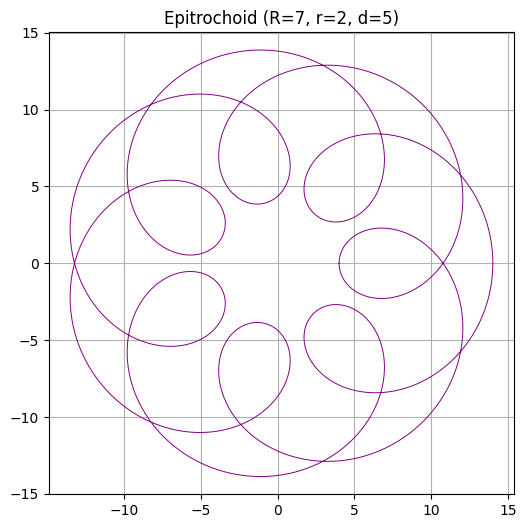

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

R = 7
r = 2
d = 5

revolutions = r // gcd(R, r)
theta = np.linspace(0, 2 * np.pi * revolutions, 2000)

x = (R + r) * np.cos(theta) - d * np.cos((R + r) * theta / r)
y = (R + r) * np.sin(theta) - d * np.sin((R + r) * theta / r)

plt.figure(figsize=(6, 6))
plt.plot(x, y, color='purple', linewidth=0.7)
plt.axis('equal')
plt.title(f"Epitrochoid (R={R}, r={r}, d={d})")
plt.grid(True)
plt.show()

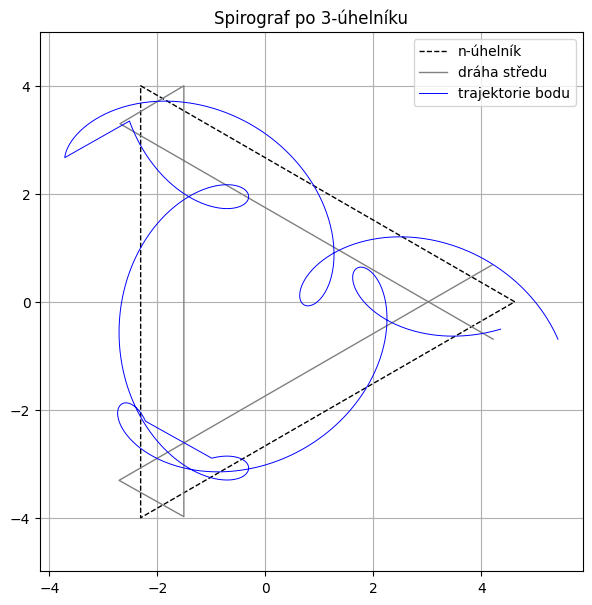

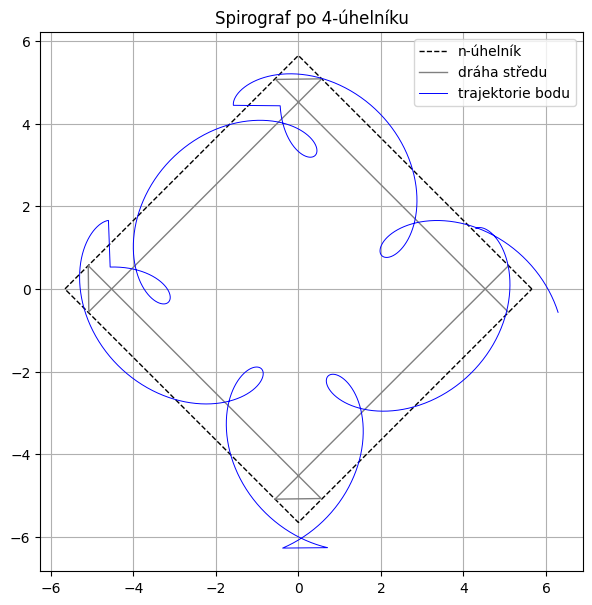

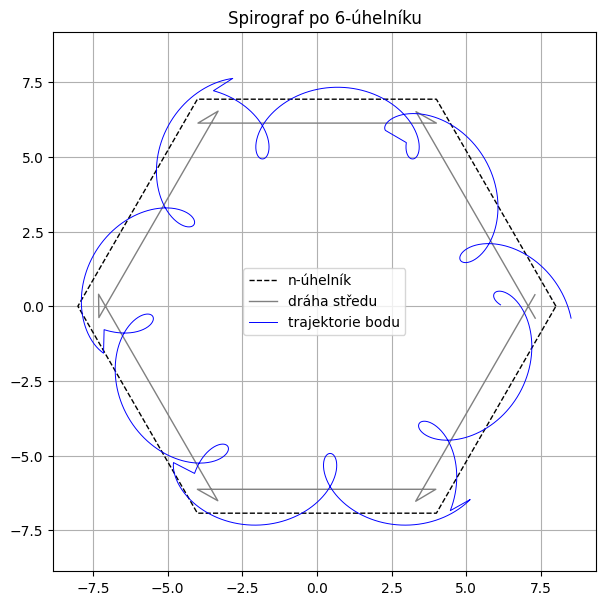

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def draw_polygon_spirograph(n_sides=4, side_length=8, r=1, d=1.5, points_per_side=400):

    R_poly = side_length / (2 * np.sin(np.pi / n_sides))

    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False)
    vertices = np.column_stack((R_poly * np.cos(angles), R_poly * np.sin(angles)))

    vertices_closed = np.vstack([vertices, vertices[0]])


    center_points = []
    normals = []
    path_lengths = []

    total_length = 0.0

    for i in range(n_sides):
        A = vertices[i]
        B = vertices[(i + 1) % n_sides]

        edge = B - A
        edge_length = np.linalg.norm(edge)
        tangent = edge / edge_length

        normal = np.array([-tangent[1], tangent[0]])

        A_shift = A + r * normal
        B_shift = B + r * normal

        t_values = np.linspace(0, 1, points_per_side, endpoint=False)
        for t in t_values:
            C = (1 - t) * A_shift + t * B_shift
            center_points.append(C)
            normals.append(normal)
            path_lengths.append(total_length + t * edge_length)

        total_length += edge_length

    center_points = np.array(center_points)
    normals = np.array(normals)
    path_lengths = np.array(path_lengths)

    phi = path_lengths / r


    x = center_points[:, 0] + d * np.cos(phi)
    y = center_points[:, 1] + d * np.sin(phi)

    plt.figure(figsize=(7, 7))

    plt.plot(vertices_closed[:, 0], vertices_closed[:, 1], 'k--', linewidth=1, label='n-úhelník')

    plt.plot(center_points[:, 0], center_points[:, 1], color='gray', linewidth=1, label='dráha středu')

    plt.plot(x, y, color='blue', linewidth=0.7, label='trajektorie bodu')

    plt.axis('equal')
    plt.grid(True)
    plt.title(f"Spirograf po {n_sides}-úhelníku")
    plt.legend()
    plt.show()

draw_polygon_spirograph(n_sides=3, side_length=8, r=0.8, d=1.2)
draw_polygon_spirograph(n_sides=4, side_length=8, r=0.8, d=1.2)
draw_polygon_spirograph(n_sides=6, side_length=8, r=0.8, d=1.2)